# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Capstone — Google Search Ranking & Discoverability

## Refresh / Content Opportunity Scoring

This project studies whether historical search-performance signals can be used to identify content that is likely to experience future performance decline.

The output is a ranked decision-support queue that helps content reviewers prioritize pages for review.

This analysis does not claim to predict Google's ranking algorithm or guarantee that refreshing a page will improve performance.

## 1. Question

### Research Question

Can historical search visibility and click-performance signals identify content that is likely to experience future search-performance decline?

### Decision Supported

The goal is to help a content or SEO reviewer decide which content should be reviewed first for possible refresh or improvement.

The model produces a ranked priority queue rather than an automatic refresh decision.

### Lane

Refresh / Content Opportunity Scoring.

## 2. Data

The analysis uses the pseudonymized FlyRank internship warehouse release.

Historical data from March, April, and May 2026 are used to construct content-level features.

June 2026 is reserved as a future outcome window.

The analysis uses Google Search Console availability fields, impressions, and clicks.

Client names, domains, URLs, private queries, credentials, and other identifying information are not used.

The data are aggregated to the content level before modeling.

In [1]:
!pip install -q huggingface_hub duckdb pyarrow fsspec

from huggingface_hub import login
from google.colab import userdata
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

hf_token = userdata.get("HF_TOKEN")

login(token=hf_token)

con = duckdb.connect()

con.sql("INSTALL httpfs;")
con.sql("LOAD httpfs;")

con.sql(f"""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{hf_token}'
);
""")

print("FlyRank warehouse connection ready.")

FlyRank warehouse connection ready.


In [2]:
march_path = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet"

test = con.sql(f"""
    SELECT *
    FROM read_parquet('{march_path}')
    LIMIT 5
""").df()

print("March 2026 file loaded successfully.")
print("Columns:")
print(test.columns.tolist())

display(test)

March 2026 file loaded successfully.
Columns:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,<NA>,20,0,67,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,<NA>,1,0,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,<NA>,125,1,616,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,<NA>,7,0,28,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,<NA>,11,0,25,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03


In [3]:
historical_query = """
SELECT
    content_hash_id,
    SUM(gsc_impressions) AS impressions_90d,
    SUM(gsc_clicks) AS clicks_90d,
    AVG(gsc_impressions) AS avg_daily_impressions,
    AVG(gsc_clicks) AS avg_daily_clicks,
    COUNT(*) FILTER (
        WHERE gsc_impressions > 0
    ) AS days_with_impressions,
    COUNT(*) FILTER (
        WHERE gsc_clicks > 0
    ) AS days_with_clicks,
    AVG(
        CASE
            WHEN gsc_impressions > 0
            THEN gsc_clicks * 1.0 / gsc_impressions
            ELSE NULL
        END
    ) AS avg_ctr,
    MAX(gsc_impressions) AS max_impressions,
    COUNT(*) AS observed_days
FROM read_parquet([
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet',
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/data_0.parquet',
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-05/data_0.parquet'
])
WHERE gsc_data_available IS TRUE
GROUP BY content_hash_id
"""

features = con.sql(historical_query).df()

features["historical_ctr"] = np.where(
    features["impressions_90d"] > 0,
    features["clicks_90d"] / features["impressions_90d"],
    np.nan
)

print("Historical feature dataset:", features.shape)

display(features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Historical feature dataset: (258233, 11)


,content_hash_id,impressions_90d,clicks_90d,avg_daily_impressions,avg_daily_clicks,days_with_impressions,days_with_clicks,avg_ctr,max_impressions,observed_days,historical_ctr
0,content_2e6360ad20fd7107,2283.0,1.0,24.815217,0.010870,92,1,0.000543,119,92,0.000438
1,content_ac8663da7484669a,93.0,1.0,1.788462,0.019231,52,1,0.009615,8,52,0.010753
2,content_d49a012dcb924e31,560.0,0.0,6.363636,0.000000,88,0,0.000000,32,88,0.000000
3,content_614baf2af4330bd7,1239.0,1.0,13.615385,0.010989,91,1,0.000314,48,91,0.000807
4,content_4a1ca0fa5c177e0c,44.0,0.0,1.517241,0.000000,29,0,0.000000,4,29,0.000000


In [4]:
future_query = """
SELECT
    content_hash_id,
    SUM(gsc_impressions) AS future_impressions,
    SUM(gsc_clicks) AS future_clicks,
    COUNT(*) FILTER (
        WHERE gsc_impressions > 0
    ) AS future_days_with_impressions,
    COUNT(*) AS future_days
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-06/data_0.parquet'
)
WHERE gsc_data_available IS TRUE
GROUP BY content_hash_id
"""

future = con.sql(future_query).df()

print("Future dataset:", future.shape)

display(future.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Future dataset: (208636, 5)


,content_hash_id,future_impressions,future_clicks,future_days_with_impressions,future_days
0,content_fdeb087480dcd176,1.0,0.0,1,1
1,content_6ee31d7d123af886,11.0,1.0,6,6
2,content_608a1d7a1ce91b44,67.0,0.0,27,27
3,content_65568e7c035d631f,17.0,0.0,13,13
4,content_50bf809645e7a321,5.0,0.0,5,5


In [5]:
dataset = features.merge(
    future,
    on="content_hash_id",
    how="inner"
)

dataset["historical_daily_clicks"] = (
    dataset["clicks_90d"] /
    dataset["observed_days"]
)

dataset["future_daily_clicks"] = np.where(
    dataset["future_days"] > 0,
    dataset["future_clicks"] / dataset["future_days"],
    np.nan
)

dataset["click_change_pct"] = np.where(
    dataset["historical_daily_clicks"] > 0,
    (
        dataset["future_daily_clicks"]
        - dataset["historical_daily_clicks"]
    )
    / dataset["historical_daily_clicks"],
    np.nan
)

dataset["future_decline_label"] = (
    (dataset["clicks_90d"] >= 5)
    &
    (dataset["click_change_pct"] <= -0.20)
).astype(int)

print("Final dataset:", dataset.shape)

print("\nLabel distribution:")

display(
    dataset["future_decline_label"].value_counts()
)

print(
    "\nPositive rate:",
    round(
        dataset["future_decline_label"].mean(),
        4
    )
)

Final dataset: (187595, 19)

Label distribution:


,count
future_decline_label,
0,153658
1,33937



Positive rate: 0.1809


In [6]:
print("Rows:", len(dataset))

print(
    "Unique content:",
    dataset["content_hash_id"].nunique()
)

print("\nMissing values:")

display(
    dataset.isna()
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

print("\nChange distribution:")

display(
    dataset["click_change_pct"].describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

Rows: 187595
Unique content: 187595

Missing values:


,0
click_change_pct,83571
impressions_90d,0
content_hash_id,0
clicks_90d,0
avg_daily_impressions,0
days_with_impressions,0
avg_daily_clicks,0
avg_ctr,0
max_impressions,0
observed_days,0



Change distribution:


,click_change_pct
count,104024.000000
mean,-0.056458
std,1.878500
min,-1.000000
1%,-1.000000
5%,-1.000000
10%,-1.000000
25%,-1.000000
50%,-0.584181
75%,0.100000


## 3. Methodology

### Historical Feature Window

March–May 2026 are used as the historical observation period.

### Future Outcome Window

June 2026 is treated as the future outcome period.

### Features

The model uses historical search-performance features including:

- total impressions
- total clicks
- average daily impressions
- average daily clicks
- days with impressions
- days with clicks
- historical CTR
- maximum daily impressions

### Label

A content item receives a decline label of 1 when:

1. it has at least 5 historical clicks, and
2. average daily clicks decrease by at least 20% in June compared with the historical period.

Otherwise the label is 0.

This is an operational proxy for future decline.
Approximately 83,571 content items had no recorded clicks during the historical (March–May) window, making a percent-change calculation impossible for them. These items are treated as non-declining by default, since the label definition requires at least 5 historical clicks to qualify for a decline label in the first place. This means the model is only evaluated on content that had a meaningful baseline of traffic to decline from.

### Baseline

The transparent baseline ranks content primarily by historical search visibility.

### Model

The primary model is logistic regression because the target is binary and the predicted probability provides an interpretable ranking score.

### Validation

The experiment first separates a held-out test set from the historical-feature/future-outcome dataset. Model and baseline are evaluated on the same test set.

### Leakage Check

Future June performance is used only to construct the outcome label and is not included among the model features.

No client names, URLs, private queries, or decision/action fields are used.

In [7]:
def minmax(series):
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            0.5,
            index=series.index
        )

    return (
        (series - minimum)
        / (maximum - minimum)
    )

dataset["visibility_score"] = minmax(
    np.log1p(dataset["impressions_90d"])
)

dataset["baseline_score"] = (
    dataset["visibility_score"]
)

print("Baseline created.")

display(
    dataset[
        [
            "content_hash_id",
            "impressions_90d",
            "baseline_score"
        ]
    ].head()
)

Baseline created.


,content_hash_id,impressions_90d,baseline_score
0,content_2e6360ad20fd7107,2283.0,0.509390
1,content_ac8663da7484669a,93.0,0.278562
2,content_d49a012dcb924e31,560.0,0.407812
3,content_614baf2af4330bd7,1239.0,0.465197
4,content_4a1ca0fa5c177e0c,44.0,0.225266


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

feature_cols = [
    "impressions_90d",
    "clicks_90d",
    "historical_ctr",
    "avg_daily_impressions",
    "avg_daily_clicks",
    "days_with_impressions",
    "days_with_clicks",
    "max_impressions"
]

model_data = dataset[
    [
        "content_hash_id"
    ]
    + feature_cols
    + ["future_decline_label"]
].copy()

model_data = model_data.replace(
    [np.inf, -np.inf],
    np.nan
)

X = model_data[feature_cols]

y = model_data["future_decline_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

model.fit(
    X_train,
    y_train
)

print("Model trained successfully.")

print(
    "Training rows:",
    len(X_train)
)

print(
    "Test rows:",
    len(X_test)
)

Model trained successfully.
Training rows: 150076
Test rows: 37519


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [9]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report
)

test_probability = model.predict_proba(
    X_test
)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    test_probability
)

average_precision = average_precision_score(
    y_test,
    test_probability
)

print(
    "ROC-AUC:",
    round(roc_auc, 4)
)

print(
    "Average Precision:",
    round(average_precision, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        (test_probability >= 0.5).astype(int),
        zero_division=0
    )
)

ROC-AUC: 0.9244
Average Precision: 0.6438

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93     30732
           1       0.64      0.84      0.73      6787

    accuracy                           0.89     37519
   macro avg       0.80      0.87      0.83     37519
weighted avg       0.90      0.89      0.89     37519



In [10]:
def precision_at_k(
    y_true,
    scores,
    k
):
    order = np.argsort(scores)[::-1]

    top_k = order[:k]

    return np.mean(
        np.asarray(y_true)[top_k]
    )


test_ids = model_data.loc[
    X_test.index,
    "content_hash_id"
]

baseline_test = (
    dataset
    .set_index("content_hash_id")
    .loc[
        test_ids,
        "baseline_score"
    ]
    .values
)

results = []

for k in [10, 20, 50, 100]:

    model_precision = precision_at_k(
        y_test,
        test_probability,
        k
    )

    baseline_precision = precision_at_k(
        y_test,
        baseline_test,
        k
    )

    results.append({
        "K": k,
        "Model Precision@K":
            model_precision,
        "Baseline Precision@K":
            baseline_precision
    })

results_df = pd.DataFrame(results)

display(results_df)

,K,Model Precision@K,Baseline Precision@K
0,10,0.70,0.90
1,20,0.65,0.90
2,50,0.62,0.72
3,100,0.58,0.72


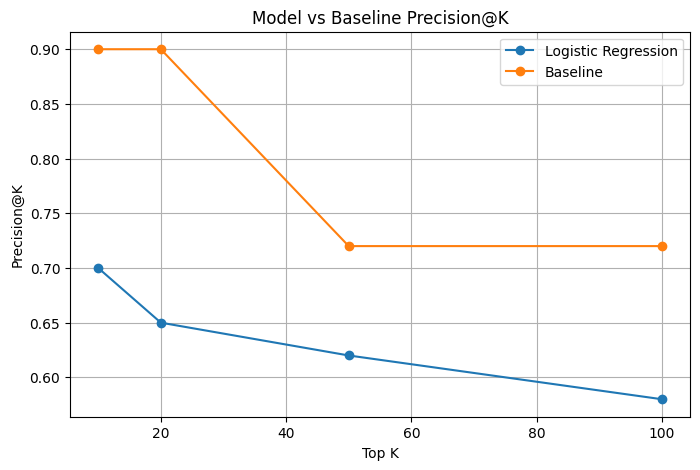

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["K"],
    results_df["Model Precision@K"],
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    results_df["K"],
    results_df["Baseline Precision@K"],
    marker="o",
    label="Baseline"
)

plt.xlabel("Top K")
plt.ylabel("Precision@K")
plt.title("Model vs Baseline Precision@K")
plt.legend()
plt.grid(True)

plt.show()

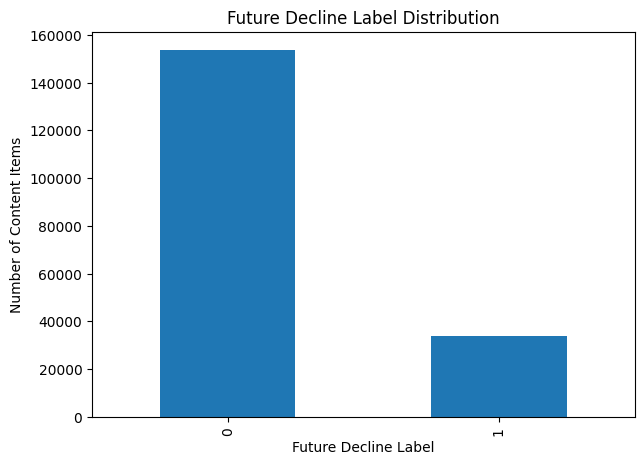

In [12]:
plt.figure(figsize=(7, 5))

dataset["future_decline_label"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Future Decline Label")
plt.ylabel("Number of Content Items")
plt.title("Future Decline Label Distribution")

plt.show()

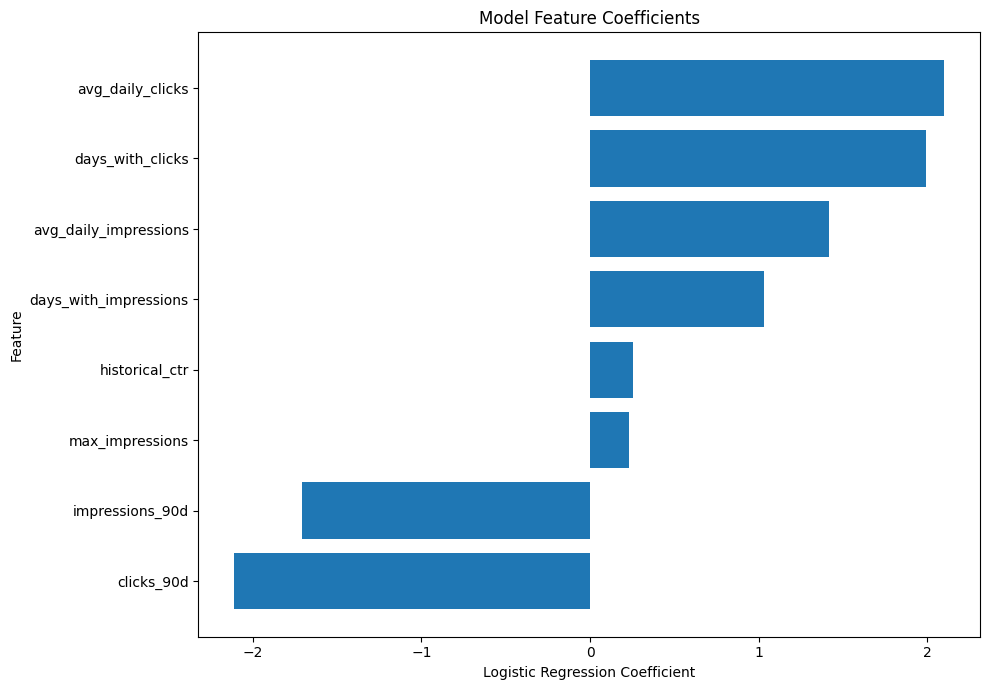

In [13]:
classifier = model.named_steps["classifier"]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": classifier.coef_[0]
})

coef_df = coef_df.sort_values(
    "coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    coef_df["feature"],
    coef_df["coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Model Feature Coefficients")

plt.tight_layout()

plt.show()

## 4. Results

The model and transparent baseline were evaluated on the same held-out test set.

Precision@K is the primary ranking metric because the practical use case is to identify a small set of content items for human review.

The experiment reports Precision@10, Precision@20, Precision@50, and Precision@100, together with ROC-AUC and Average Precision.

The results should be interpreted as evidence about ranking performance within the released dataset. They do not demonstrate that the model predicts Google's ranking algorithm or that refreshing content will cause improved performance.

The final conclusion should be based on the measured comparison between the model and baseline rather than assuming that the machine-learning model is superior.

## 5. Limitations

This analysis is observational and intended for decision support.

The future-decline label is an operational proxy based on changes in search clicks. It does not represent whether refreshing a page would actually improve performance.

The experiment uses a single future evaluation window, so it does not establish performance across multiple future periods.

The released dataset does not contain every factor that may influence search performance, including detailed page quality, competitor changes, SERP features, editorial changes, or external changes in search demand.

The model should therefore be used to prioritize human review rather than automatically trigger content changes.

The analysis also does not prove which factors Google uses in its ranking systems.

In [14]:
dataset["model_probability"] = model.predict_proba(
    dataset[feature_cols]
)[:, 1]

dataset["opportunity_score"] = (
    100
    * (
        0.70 * dataset["model_probability"]
        + 0.30 * dataset["baseline_score"]
    )
)

ranked = dataset.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

ranked["rank"] = (
    np.arange(1, len(ranked) + 1)
)

display(
    ranked[
        [
            "rank",
            "content_hash_id",
            "opportunity_score",
            "model_probability",
            "baseline_score"
        ]
    ].head(20)
)

,rank,content_hash_id,opportunity_score,model_probability,baseline_score
0,1,content_21309e9a83c83653,97.095195,1.000000,0.903173
1,2,content_545bb6cc7081ded3,97.087239,0.999781,0.903418
2,3,content_8d7d99f109e19aa2,96.985737,0.999406,0.900910
3,4,content_77276ad7a26f4905,96.918158,0.997893,0.902189
4,5,content_62770e1299963fe4,96.594148,0.999998,0.886476
5,6,content_44f34c0a90047651,96.490442,0.999995,0.883027
6,7,content_963de14b1f58978f,96.440738,0.999997,0.881364
7,8,content_943dc881428182b8,96.425486,1.000000,0.880850
8,9,content_0e03de7680314cd5,96.331150,0.981777,0.920225
9,10,content_e578ac84778da489,96.168111,0.997056,0.879140


## 6. Ranked Recommendations

The final ranking should be treated as a review queue rather than an automatic publishing decision.

### 1. Prioritize high-scoring content

Review content with high opportunity scores first, particularly when it has meaningful historical search visibility.

### 2. Investigate potential decline

Review the historical and June performance pattern before deciding whether a refresh is appropriate.

### 3. Investigate CTR opportunities

Content with strong visibility but weak historical CTR may warrant review of titles, snippets, and intent alignment.

### 4. Review before refreshing

A high opportunity score does not mean that a content refresh will necessarily improve performance.

### 5. Protect strong performers

Content with low opportunity scores should not automatically be changed. Monitoring may be more appropriate.

### 6. Keep humans in the loop

The ranking is a prioritization mechanism. Final editorial decisions should be made through human review.

## 7. Artifacts the Paper Embeds

The following artifacts are generated from the capstone analysis and will be used in the deployed research paper:

1. Model vs baseline Precision@K comparison
2. Future decline label distribution
3. Logistic regression feature coefficients
4. Top-20 content opportunity ranking table

In [15]:
impression_median = (
    ranked["impressions_90d"].median()
)

ctr_median = (
    ranked["historical_ctr"].median()
)

def get_reason(row):

    reasons = []

    if row["impressions_90d"] >= impression_median:
        reasons.append(
            "HIGH_VISIBILITY"
        )

    if row["historical_ctr"] < ctr_median:
        reasons.append(
            "LOW_HISTORICAL_CTR"
        )

    if row["clicks_90d"] >= ranked["clicks_90d"].median():
        reasons.append(
            "MEANINGFUL_CLICK_VOLUME"
        )

    if row["model_probability"] >= 0.75:
        reasons.append(
            "HIGH_MODEL_RISK"
        )

    if not reasons:
        reasons.append(
            "NO_SINGLE_DOMINANT_SIGNAL"
        )

    return " + ".join(
        reasons[:3]
    )


def get_action(score):

    if score >= 75:
        return "REFRESH"

    elif score >= 50:
        return "REVIEW"

    elif score >= 25:
        return "MONITOR"

    else:
        return "PROTECT"


ranked["reason"] = ranked.apply(
    get_reason,
    axis=1
)

ranked["action"] = ranked[
    "opportunity_score"
].apply(
    get_action
)

top20 = ranked.head(20)

display(
    top20[
        [
            "rank",
            "content_hash_id",
            "opportunity_score",
            "reason",
            "action"
        ]
    ]
)

,rank,content_hash_id,opportunity_score,reason,action
0,1,content_21309e9a83c83653,97.095195,HIGH_VISIBILITY + MEANINGFUL_CLICK_VOLUME + HI...,REFRESH
1,2,content_545bb6cc7081ded3,97.087239,HIGH_VISIBILITY + MEANINGFUL_CLICK_VOLUME + HI...,REFRESH
2,3,content_8d7d99f109e19aa2,96.985737,HIGH_VISIBILITY + MEANINGFUL_CLICK_VOLUME + HI...,REFRESH
3,4,content_77276ad7a26f4905,96.918158,HIGH_VISIBILITY + MEANINGFUL_CLICK_VOLUME + HI...,REFRESH
4,5,content_62770e1299963fe4,96.594148,HIGH_VISIBILITY + MEANINGFUL_CLICK_VOLUME + HI...,REFRESH
5,6,content_44f34c0a90047651,96.490442,HIGH_VISIBILITY + LOW_HISTORICAL_CTR + MEANING...,REFRESH
6,7,content_963de14b1f58978f,96.440738,HIGH_VISIBILITY + MEANINGFUL_CLICK_VOLUME + HI...,REFRESH
7,8,content_943dc881428182b8,96.425486,HIGH_VISIBILITY + MEANINGFUL_CLICK_VOLUME + HI...,REFRESH
8,9,content_0e03de7680314cd5,96.331150,HIGH_VISIBILITY + MEANINGFUL_CLICK_VOLUME + HI...,REFRESH
9,10,content_e578ac84778da489,96.168111,HIGH_VISIBILITY + MEANINGFUL_CLICK_VOLUME + HI...,REFRESH


## Self-check

* [x] Research question defined
* [x] Decision supported defined
* [x] Dataset documented
* [x] Data quality inspected
* [x] Label defined and its proxy limitation explained
* [x] Leakage-sensitive fields excluded from model features
* [x] Transparent baseline created
* [x] Logistic regression model trained
* [x] Same test split used for baseline and model
* [x] Precision@K evaluated
* [x] ROC-AUC evaluated
* [x] Average Precision evaluated
* [x] Top-20 ranked queue generated
* [x] Reason codes generated
* [x] Recommended actions generated
* [x] Limitations documented
* [x] Charts generated
* [x] Output artifacts saved

The notebook should be run from top to bottom without errors before committing it to `work/notebooks/`.
